In [1]:
import pandas as pd
import re

# 서울시 대로변 횡단보도 위치정보

## 1. 데이터 불러오기 및 확인

In [2]:
df_raw = pd.read_csv(
    '/Users/danha/Desktop/IT/project/team_project_brew_map/git/data/서울시 대로변 횡단보도 위치정보.csv',
    encoding="cp949"
)

print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head()

Shape: (31080, 14)
Columns: ['노드링크 유형', '노드 WKT', '노드 ID', '노드 유형 코드', '링크 WKT', '링크 ID', '링크 유형 코드', '시작노드 ID', '종료노드 ID', '링크 길이', '시군구코드', '시군구명', '읍면동코드', '읍면동명']


,노드링크 유형,노드 WKT,노드 ID,노드 유형 코드,링크 WKT,링크 ID,링크 유형 코드,시작노드 ID,종료노드 ID,링크 길이,시군구코드,시군구명,읍면동코드,읍면동명
0,NODE,POINT(127.00178102814176 37.581945188630954),137304,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111017200,명륜4가
1,NODE,POINT(126.99701335026714 37.577184625449455),136429,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111013000,와룡동
2,NODE,POINT(126.99697789522051 37.57649508793737),136430,0.0,NaN,0,NaN,NaN,NaN,NaN,1111000000,종로구,1111015900,원남동
3,LINK,NaN,0,NaN,LINESTRING(126.99776898185851 37.5724514306032...,275609,1000.0,136634.0,136635.0,21.444,1111000000,종로구,1111015700,인의동
4,LINK,NaN,0,NaN,LINESTRING(127.00870271221665 37.5714078767855...,30686,1011.0,153186.0,153185.0,41.190,1111000000,종로구,1111016400,종로6가


In [3]:
print('=== 데이터 타입 ===')
print(df_raw.dtypes)
print()
print('=== 결측값 현황 ===')
print(df_raw.isnull().sum())
print()
print('=== 노드링크 유형 분포 ===')
print(df_raw['노드링크 유형'].value_counts())

=== 데이터 타입 ===
노드링크 유형      object
노드 WKT       object
노드 ID         int64
노드 유형 코드    float64
링크 WKT       object
링크 ID         int64
링크 유형 코드    float64
시작노드 ID     float64
종료노드 ID     float64
링크 길이       float64
시군구코드         int64
시군구명         object
읍면동코드         int64
읍면동명         object
dtype: object

=== 결측값 현황 ===
노드링크 유형         0
노드 WKT      11562
노드 ID           0
노드 유형 코드    11562
링크 WKT      19518
링크 ID           0
링크 유형 코드    19518
시작노드 ID     19518
종료노드 ID     19518
링크 길이       19518
시군구코드           0
시군구명            0
읍면동코드           0
읍면동명            0
dtype: int64

=== 노드링크 유형 분포 ===
노드링크 유형
NODE    19518
LINK    11562
Name: count, dtype: int64


## 2. 핵심 데이터 추출

- `NODE` : 횡단보도 위치 좌표
- `LINK` : 노드 간 연결 경로 정보

In [4]:
# NODE 행만 추출 (횡단보도 위치 좌표)
df = df_raw[df_raw['노드링크 유형'] == 'NODE'].copy()

# NODE에서 의미 있는 컬럼만 선택
node_cols = ['노드링크 유형', '노드 WKT', '시군구명', '읍면동명']
df = df[node_cols]

print(f'추출 후 Shape: {df.shape}')
df.head()

추출 후 Shape: (19518, 4)


,노드링크 유형,노드 WKT,시군구명,읍면동명
0,NODE,POINT(127.00178102814176 37.581945188630954),종로구,명륜4가
1,NODE,POINT(126.99701335026714 37.577184625449455),종로구,와룡동
2,NODE,POINT(126.99697789522051 37.57649508793737),종로구,원남동
6,NODE,POINT(126.99728538406251 37.57723640609517),종로구,연건동
9,NODE,POINT(126.98967151380992 37.57729290753758),종로구,와룡동


## 3. 열 이름 영소문자로 변경 및 type 행 생성

In [ ]:
col_rename = {
    '노드링크 유형' : 'node_link_type',
    '노드 WKT'    : 'wkt',
    '시군구명'     : 'sigungu_nm',
    '읍면동명'     : 'emd_nm'
}
df['type'] = '횡단보도'

df = df.rename(columns=col_rename)
print('변환된 컬럼명:', df.columns.tolist())
df.head()


변환된 컬럼명: ['node_link_type', 'wkt', 'sigungu_nm', 'emd_nm', 'type']


,node_link_type,wkt,sigungu_nm,emd_nm,type
0,NODE,POINT(127.00178102814176 37.581945188630954),종로구,명륜4가,횡단보도
1,NODE,POINT(126.99701335026714 37.577184625449455),종로구,와룡동,횡단보도
2,NODE,POINT(126.99697789522051 37.57649508793737),종로구,원남동,횡단보도
6,NODE,POINT(126.99728538406251 37.57723640609517),종로구,연건동,횡단보도
9,NODE,POINT(126.98967151380992 37.57729290753758),종로구,와룡동,횡단보도


## 5. 중복값 확인

In [6]:
print(f'처리 전 행 수: {len(df)}')
print(f'wkt 기준 중복 수: {df.duplicated(subset=["wkt"]).sum()}')

dup_all = df[df.duplicated(keep=False)]
df = df.drop_duplicates(subset=['wkt'])

dup_all.head()

처리 전 행 수: 19518
wkt 기준 중복 수: 3


,node_link_type,wkt,sigungu_nm,emd_nm,type
24235,NODE,POINT(127.04120559699655 37.48531067965658),서초구,양재동,횡단보도
24238,NODE,POINT(127.04120559699655 37.48531067965658),서초구,양재동,횡단보도
24595,NODE,POINT(127.02019281444447 37.51383086942569),서초구,잠원동,횡단보도
24597,NODE,POINT(127.02019281444447 37.51383086942569),서초구,잠원동,횡단보도


In [7]:
df = df.drop_duplicates(subset=['wkt'])
print(f'중복 제거 후 행 수: {len(df)}')

중복 제거 후 행 수: 19515


## 6. WKT 컬럼에서 경도 / 위도 분리

`POINT(127.002153... 37.573533...)` → `longitude` / `latitude` 분리

In [8]:
def parse_wkt(wkt_str):
    
    match = re.search(r'POINT\(([\d.]+)\s+([\d.]+)\)', str(wkt_str))
    if match:
        return float(match.group(1)), float(match.group(2))
    return None, None

df[['lng', 'lat']] = df['wkt'].apply(
    lambda x: pd.Series(parse_wkt(x))
)

print('파싱 실패 건수:', df['lng'].isnull().sum())
print()
print(df[['wkt', 'lng', 'lat']].head())

파싱 실패 건수: 0

                                            wkt         lng        lat
0  POINT(127.00178102814176 37.581945188630954)  127.001781  37.581945
1  POINT(126.99701335026714 37.577184625449455)  126.997013  37.577185
2   POINT(126.99697789522051 37.57649508793737)  126.996978  37.576495
6   POINT(126.99728538406251 37.57723640609517)  126.997285  37.577236
9   POINT(126.98967151380992 37.57729290753758)  126.989672  37.577293


## 7. 이상치 제거

### 7.1 이상치 확인

In [9]:
LNG_MIN, LNG_MAX = 126.76, 127.18
LAT_MIN, LAT_MAX = 37.43, 37.70

is_outlier = (
    ~df['lng'].between(LNG_MIN, LNG_MAX) |
    ~df['lat'].between(LAT_MIN, LAT_MAX)
)

outliers = df[is_outlier]
print(f'이상치 {len(outliers)}건')
print()
outliers[['node_link_type', 'lng', 'lat', 'sigungu_nm', 'emd_nm']]

이상치 19건



,node_link_type,lng,lat,sigungu_nm,emd_nm
29425,NODE,127.181400,37.561834,강동구,강일동
29674,NODE,127.181549,37.561865,강동구,강일동
29675,NODE,127.181669,37.561499,강동구,강일동
29684,NODE,127.180228,37.561282,강동구,강일동
29686,NODE,127.180283,37.561307,강동구,강일동
29687,NODE,127.180269,37.561481,강동구,강일동
29688,NODE,127.180197,37.561510,강동구,강일동
29689,NODE,127.180152,37.561552,강동구,강일동
29998,NODE,127.181528,37.561463,강동구,강일동
30190,NODE,127.180014,37.561950,강동구,강일동


### 7.2 이상치인 이유 찾기

In [10]:
print('경도 초과 (동쪽):', len(df[df['lng'] > LNG_MAX]))
print('경도 미달 (서쪽):', len(df[df['lng'] < LNG_MIN]))
print('위도 초과 (북쪽):', len(df[df['lat'] > LAT_MAX]))
print('위도 미달 (남쪽):', len(df[df['lat'] < LAT_MIN]))

경도 초과 (동쪽): 19
경도 미달 (서쪽): 0
위도 초과 (북쪽): 0
위도 미달 (남쪽): 0


/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_71151/1388463930.py:36: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_71151/1388463930.py:36: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_71151/1388463930.py:36: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_71151/1388463930.py:36: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_71151/1388463930.py:36: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipyke

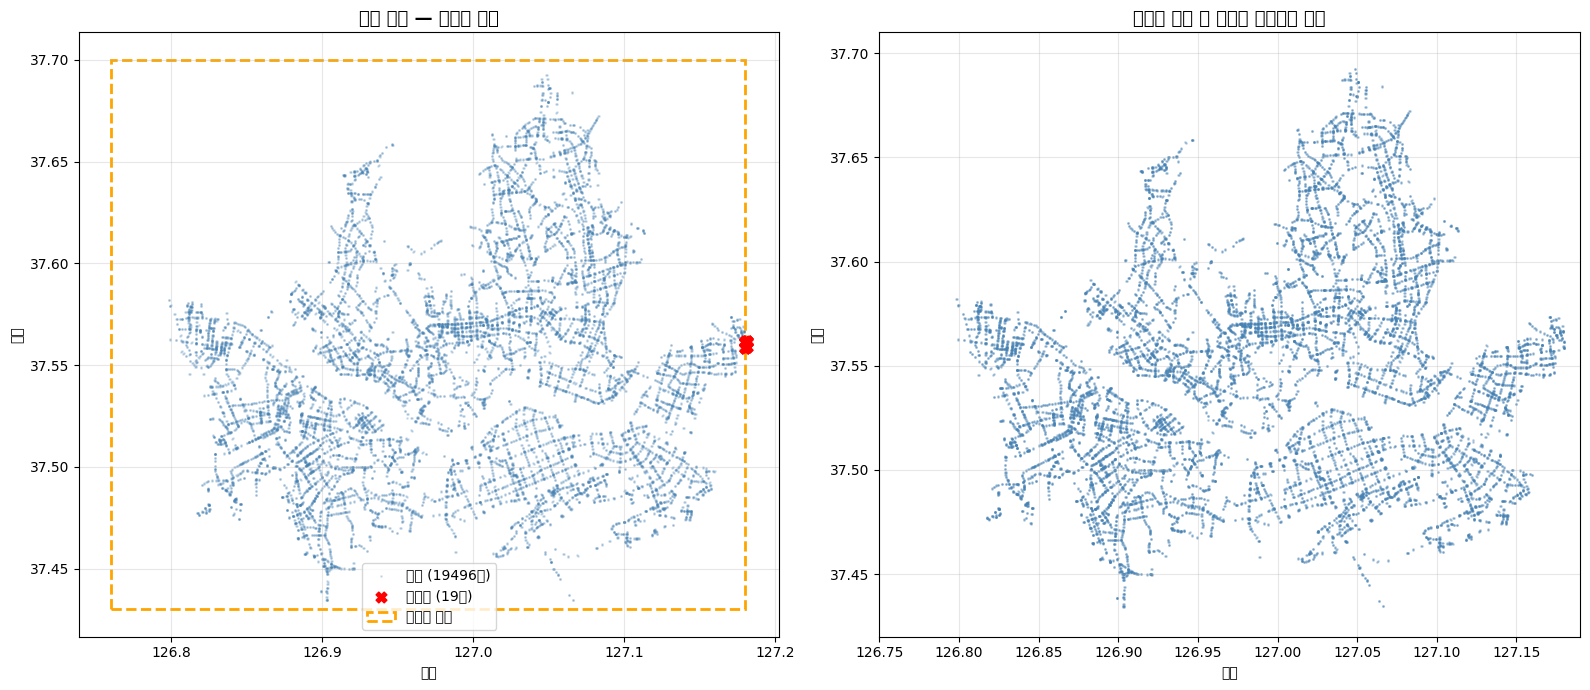

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

normal   = df[~is_outlier]
outliers = df[is_outlier]

# 왼쪽: 전체 뷰 (이상치가 어디 찍혔는지)
ax1 = axes[0]
ax1.scatter(normal['lng'], normal['lat'],
            s=1, alpha=0.2, color='steelblue', label=f'정상 ({len(normal)}건)')
ax1.scatter(outliers['lng'], outliers['lat'],
            s=60, alpha=1.0, color='red', marker='X', zorder=5,
            label=f'이상치 ({len(outliers)}건)')
rect = mpatches.FancyBboxPatch(
    (LNG_MIN, LAT_MIN), LNG_MAX - LNG_MIN, LAT_MAX - LAT_MIN,
    boxstyle='square,pad=0', linewidth=2,
    edgecolor='orange', facecolor='none', linestyle='--', label='서울시 경계'
)
ax1.add_patch(rect)
ax1.set_title('전체 분포 — 이상치 위치', fontsize=13, fontweight='bold')
ax1.set_xlabel('경도'); ax1.set_ylabel('위도')
ax1.legend(); ax1.grid(alpha=0.3)

# 오른쪽: 서울 범위만 확대 (이상치 제거 후)
ax2 = axes[1]
ax2.scatter(normal['lng'], normal['lat'],
            s=1, alpha=0.3, color='steelblue')
ax2.set_xlim(LNG_MIN - 0.01, LNG_MAX + 0.01)
ax2.set_ylim(LAT_MIN - 0.01, LAT_MAX + 0.01)
ax2.set_title('이상치 제거 후 서울시 횡단보도 분포', fontsize=13, fontweight='bold')
ax2.set_xlabel('경도'); ax2.set_ylabel('위도')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### -> 실제 서울 동쪽 끝은 약 127.20 ~ 127.22 라서 경계값을 완화시켰다.

In [12]:
LNG_MIN, LNG_MAX = 126.76, 127.22
LAT_MIN, LAT_MAX = 37.43, 37.72

is_outlier = (
    ~df['lng'].between(LNG_MIN, LNG_MAX) |
    ~df['lat'].between(LAT_MIN, LAT_MAX)
)

outliers = df[is_outlier]
print(f'이상치 {len(outliers)}건')
print()
outliers[['node_link_type', 'lng', 'lat', 'sigungu_nm', 'emd_nm']]

이상치 0건



,node_link_type,lng,lat,sigungu_nm,emd_nm


## 8. 불필요한 컬럼 정리 및 최종 데이터 확인

In [13]:
# wkt 원본 컬럼 제거 (longitude/latitude로 대체됨)
df = df.drop(columns=['wkt', 'node_link_type'])

# 컬럼 순서 정리
df = df[['lng', 'lat', 'sigungu_nm', 'emd_nm', 'type']]

# 인덱스 리셋
df = df.reset_index(drop=True)

print('=== 최종 데이터프레임 ===')
print(f'Shape: {df.shape}')
print()
print(df.dtypes)
print()
df.head(10)

=== 최종 데이터프레임 ===
Shape: (19515, 5)

lng           float64
lat           float64
sigungu_nm     object
emd_nm         object
type           object
dtype: object



,lng,lat,sigungu_nm,emd_nm,type
0,127.001781,37.581945,종로구,명륜4가,횡단보도
1,126.997013,37.577185,종로구,와룡동,횡단보도
2,126.996978,37.576495,종로구,원남동,횡단보도
3,126.997285,37.577236,종로구,연건동,횡단보도
4,126.989672,37.577293,종로구,와룡동,횡단보도
5,126.999906,37.584299,종로구,명륜2가,횡단보도
6,126.969120,37.588016,종로구,청운동,횡단보도
7,126.989648,37.577526,종로구,와룡동,횡단보도
8,126.990396,37.577597,종로구,와룡동,횡단보도
9,126.990230,37.577338,종로구,와룡동,횡단보도


In [14]:
# 전처리 완료 데이터 저장

save_path = "/Users/danha/Desktop/IT/project/team_project_brew_map/git/data/crosswalk.csv"

df.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)

저장 완료: /Users/danha/Desktop/IT/project/team_project_brew_map/git/data/crosswalk.csv
